# 03: ML-PLAC

Multiplierless piecewise linear approximation of nonlinear 1-to-1 functions.

- Approx $f(x) \approx m_i x + b_i$ on each segment $[x_i, x_{i+1}]$
- Constrain slopes $m_i$ to sums of signed powers of 2 (bit shifts in fixed point)
- $m_i \cdot x$ becomes shifts and adds. No multiplier needed.

e.g. slope $0.75 = 2^0 - 2^{-2}$, so $0.75x = x - (x \gg 2)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlplac import (
    quantize_slope,
    fit_pwl,
    eval_pwl,
    eval_pwl_shifts,
    max_abs_error,
    terms_to_str,
)


def plot_pwl(f, breakpoints, slopes, intercepts, name, mae):
    x = np.linspace(breakpoints[0], breakpoints[-1], 2000)
    y_true, y_pwl = f(x), eval_pwl(x, breakpoints, slopes, intercepts)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(8, 4), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )
    ax1.plot(x, y_true, "k-", lw=1.5, label=name)
    ax1.plot(x, y_pwl, "r--", lw=1, label=f"PWL ({len(slopes)} seg)")
    for b in breakpoints:
        ax1.axvline(b, color="gray", lw=0.3)
    ax1.legend(fontsize=9)
    ax1.set_ylabel("y")

    ax2.plot(x, y_true - y_pwl, "r-", lw=0.8)
    ax2.axhline(0, color="gray", lw=0.3)
    ax2.set_ylabel("error")
    ax2.set_xlabel("x")
    ax2.set_title(f"MAE = {mae:.2e}", fontsize=9)
    plt.tight_layout()
    plt.show()

## Slope quantization

Greedy: pick the closest power of 2 to the residual, subtract, repeat.

More terms = better approx, but more adders in hw.

In [2]:
for target in [0.762, 0.625, 0.42, -0.18, 1.0]:
    for n in [1, 2, 3]:
        terms, val = quantize_slope(target, n_terms=n)
        err = abs(target - val)
        print(
            f"  {target:+.3f}  n={n}  -> {val:+.4f}  = {terms_to_str(terms):<20s}  err={err:.4f}"
        )
    print()

  +0.762  n=1  -> +1.0000  = x                     err=0.2380
  +0.762  n=2  -> +0.7500  = x - x>>2              err=0.0120
  +0.762  n=3  -> +0.7656  = x - x>>2 + x>>6       err=0.0036

  +0.625  n=1  -> +0.5000  = x>>1                  err=0.1250
  +0.625  n=2  -> +0.6250  = x>>1 + x>>3           err=0.0000
  +0.625  n=3  -> +0.6250  = x>>1 + x>>3           err=0.0000

  +0.420  n=1  -> +0.5000  = x>>1                  err=0.0800
  +0.420  n=2  -> +0.4375  = x>>1 - x>>4           err=0.0175
  +0.420  n=3  -> +0.4219  = x>>1 - x>>4 - x>>6    err=0.0019

  -0.180  n=1  -> -0.1250  = -x>>3                 err=0.0550
  -0.180  n=2  -> -0.1875  = -x>>3 - x>>4          err=0.0075
  -0.180  n=3  -> -0.1797  = -x>>3 - x>>4 + x>>7   err=0.0003

  +1.000  n=1  -> +1.0000  = x                     err=0.0000
  +1.000  n=2  -> +1.0000  = x                     err=0.0000
  +1.000  n=3  -> +1.0000  = x                     err=0.0000



## tanh

Odd function, saturates at $\pm 1$. Steep near 0, flat at tails.

Breakpoints can be chosen by hand: tighter spacing near 0 where curvature is high.

In [3]:
bp_tanh = [-4, -2, -1, -0.5, 0, 0.5, 1, 2, 4]
slopes, intercepts, all_terms = fit_pwl(np.tanh, bp_tanh, n_terms=2)
mae = max_abs_error(np.tanh, bp_tanh, slopes, intercepts)

print(f"tanh: {len(slopes)} segments, 2 shift-add terms, MAE = {mae:.4e}")
for i in range(len(slopes)):
    print(
        f"  [{bp_tanh[i]:+5.1f}, {bp_tanh[i + 1]:+5.1f}]  {terms_to_str(all_terms[i]):<20s}  b={intercepts[i]:+.4f}"
    )

tanh: 8 segments, 2 shift-add terms, MAE = 2.4937e-02
  [ -4.0,  -2.0]  x>>6 + x>>9           b=-0.9362
  [ -2.0,  -1.0]  x>>2 - x>>4           b=-0.5990
  [ -1.0,  -0.5]  x>>1 + x>>3           b=-0.1518
  [ -0.5,  +0.0]  x - x>>4              b=-0.0020
  [ +0.0,  +0.5]  x - x>>4              b=+0.0020
  [ +0.5,  +1.0]  x>>1 + x>>3           b=+0.1518
  [ +1.0,  +2.0]  x>>2 - x>>4           b=+0.5990
  [ +2.0,  +4.0]  x>>6 + x>>9           b=+0.9362


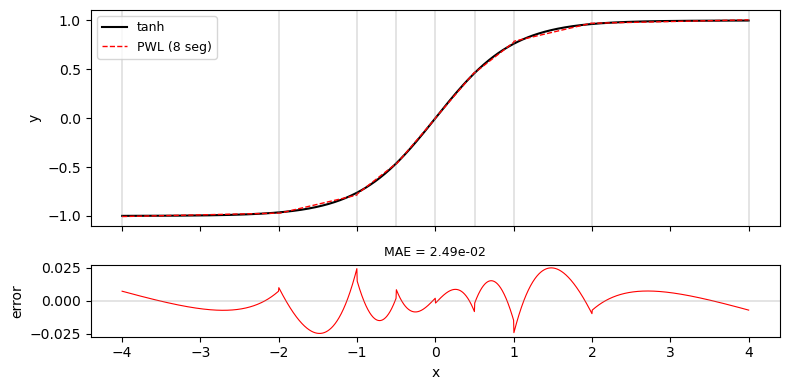

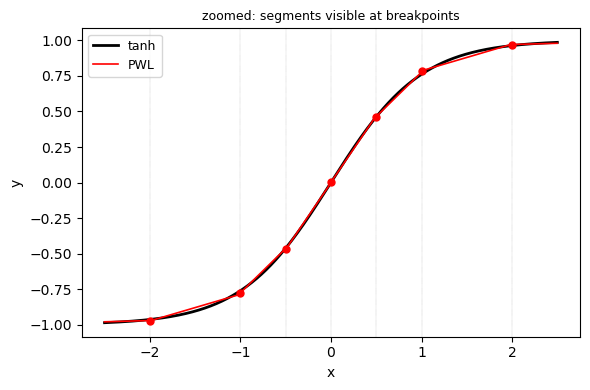

In [4]:
plot_pwl(np.tanh, bp_tanh, slopes, intercepts, "tanh", mae)

# Zoomed in on linear segments
fig, ax = plt.subplots(figsize=(6, 4))
x = np.linspace(-2.5, 2.5, 2000)
ax.plot(x, np.tanh(x), "k-", lw=2, label="tanh")
ax.plot(x, eval_pwl(x, bp_tanh, slopes, intercepts), "r-", lw=1.2, label="PWL")

# Mark breakpoints and segments
for b in bp_tanh:
    if -2.5 <= b <= 2.5:
        yb = eval_pwl(np.array([b]), bp_tanh, slopes, intercepts)[0]
        ax.plot(b, yb, "ro", ms=5, zorder=5)
        ax.axvline(b, color="gray", lw=0.3, ls=":")

ax.legend(fontsize=9)
ax.set_title("zoomed: segments visible at breakpoints", fontsize=9)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## sine

In [5]:
bp_sin = [-np.pi, -2.0, -1.0, -0.5, 0, 0.5, 1.0, 2.0, np.pi]
slopes_s, intercepts_s, terms_s = fit_pwl(np.sin, bp_sin, n_terms=2)
mae_s = max_abs_error(np.sin, bp_sin, slopes_s, intercepts_s)

print(f"sin: {len(slopes_s)} segments, MAE = {mae_s:.4e}")
for i in range(len(slopes_s)):
    print(
        f"  [{bp_sin[i]:+5.2f}, {bp_sin[i + 1]:+5.2f}]  {terms_to_str(terms_s[i]):<20s}  b={intercepts_s[i]:+.4f}"
    )

sin: 8 segments, MAE = 6.1415e-02
  [-3.14, -2.00]  -x + x>>2             b=-2.4159
  [-2.00, -1.00]  x>>4 + x>>8           b=-0.8365
  [-1.00, -0.50]  x>>1 + x>>2           b=-0.1054
  [-0.50, +0.00]  x - x>>5              b=-0.0001
  [+0.00, +0.50]  x - x>>5              b=+0.0001
  [+0.50, +1.00]  x>>1 + x>>2           b=+0.1054
  [+1.00, +2.00]  x>>4 + x>>8           b=+0.8365
  [+2.00, +3.14]  -x + x>>2             b=+2.4159


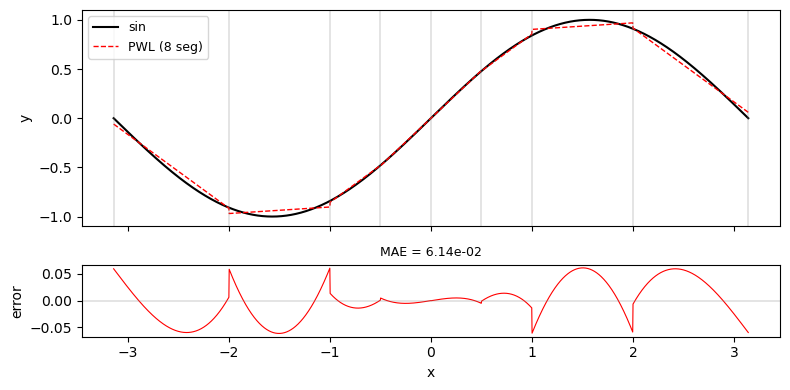

In [6]:
plot_pwl(np.sin, bp_sin, slopes_s, intercepts_s, "sin", mae_s)

## Bit-shift evaluation

`eval_pwl_shifts` uses `ldexp` (bit shift) instead of float mul. Has same result and maps directly to multiplierless hw: comparators + shifters + adders.

In [7]:
x = np.linspace(-4, 4, 10000)
y_mul = eval_pwl(x, bp_tanh, slopes, intercepts)
y_shift = eval_pwl_shifts(x, bp_tanh, all_terms, intercepts)

print(f"max diff between mul and shift-only: {np.max(np.abs(y_mul - y_shift)):.2e}")

max diff between mul and shift-only: 0.00e+00


## Segments vs error

More segments = lower error, but more comparators in hardware.

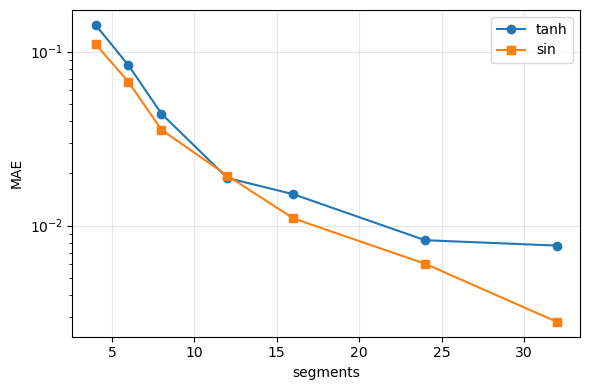

In [8]:
seg_counts = [4, 6, 8, 12, 16, 24, 32]
maes_tanh = []
maes_sin = []

for n_seg in seg_counts:
    bp = np.linspace(-4, 4, n_seg + 1).tolist()
    s, ic, _ = fit_pwl(np.tanh, bp, n_terms=2)
    maes_tanh.append(max_abs_error(np.tanh, bp, s, ic))

    bp_s = np.linspace(-np.pi, np.pi, n_seg + 1).tolist()
    s2, ic2, _ = fit_pwl(np.sin, bp_s, n_terms=2)
    maes_sin.append(max_abs_error(np.sin, bp_s, s2, ic2))

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(seg_counts, maes_tanh, "o-", label="tanh")
ax.semilogy(seg_counts, maes_sin, "s-", label="sin")
ax.set_xlabel("segments")
ax.set_ylabel("MAE")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()